In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler
import re
from imblearn.over_sampling import SMOTE
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, ConfusionMatrixDisplay

In [13]:
df = pd.read_csv('dataset.csv', delimiter=',')

In [14]:
df.head()

,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,...,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction,Date
0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,3.0,...,4,3.0,4.0,4,5,5,25,18.0,neutral or dissatisfied,2022-10-20
1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,3.0,...,1,5.0,3.0,1,4,1,1,6.0,neutral or dissatisfied,2022-10-08
2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,2.0,...,4,3.0,4.0,4,4,5,0,0.0,satisfied,2022-10-11
3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,5.0,...,2,5.0,3.0,1,4,2,11,9.0,neutral or dissatisfied,2022-10-25
4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,3.0,...,3,4.0,4.0,3,3,3,0,0.0,satisfied,2022-10-23


In [15]:
print(df.isnull().sum())

id                                      0
Gender                                 52
Customer Type                           0
Age                                     0
Type of Travel                          0
Class                                   0
Flight Distance                         0
Inflight wifi service                   0
Departure/Arrival time convenient       0
Ease of Online booking                118
Gate location                           0
Food and drink                          0
Online boarding                         0
Seat comfort                            0
Inflight entertainment                  0
On-board service                        0
Leg room service                     3315
Baggage handling                      510
Checkin service                         0
Inflight service                        0
Cleanliness                             0
Departure Delay in Minutes              0
Arrival Delay in Minutes              310
satisfaction                      

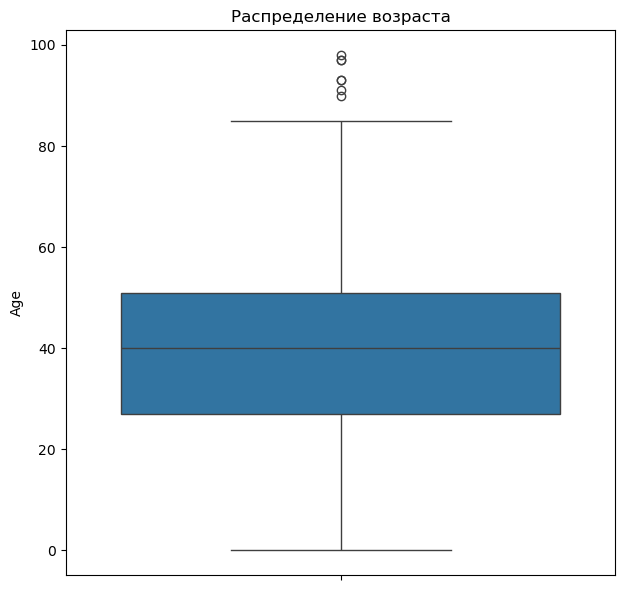

In [16]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.boxplot(y=df['Age'])
plt.title("Распределение возраста")
plt.tight_layout()
plt.show()

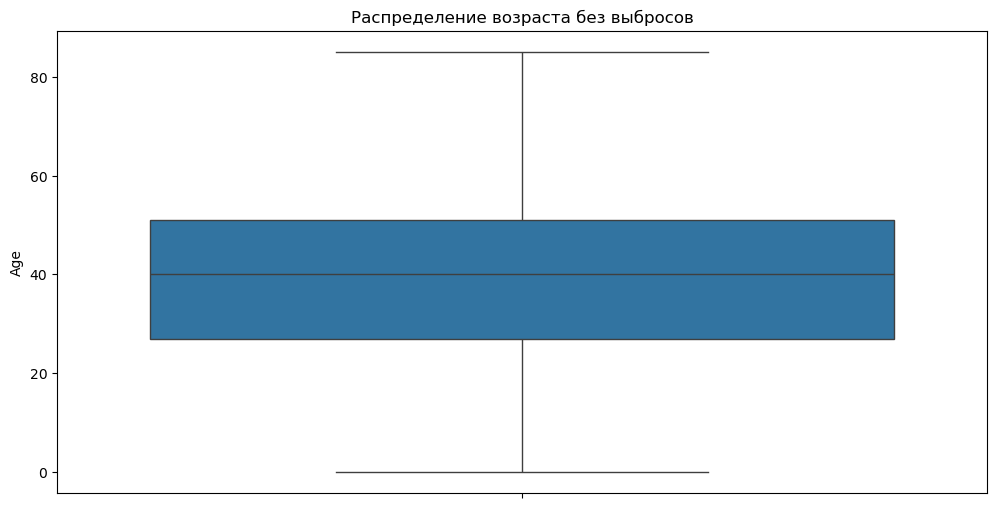

In [17]:
Q1 = df['Age'].quantile(0.25)
Q3 = df['Age'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_no_outliers = df[(df['Age'] >= lower_bound) & (df['Age'] <= upper_bound)]

plt.figure(figsize=(12, 6))
sns.boxplot(y=df_no_outliers['Age'])
plt.title("Распределение возраста без выбросов")
plt.show()

In [18]:
df['Leg room service'] = df['Leg room service'].fillna(df['Leg room service'].median())

In [19]:
df['Baggage handling'] = df['Baggage handling'].fillna(df['Baggage handling'].median())

In [20]:
df['Arrival Delay in Minutes'] = df['Arrival Delay in Minutes'].fillna(df['Arrival Delay in Minutes'].median())

In [21]:
df['Gender'] = df['Gender'].fillna(df['Gender'].mode()[0])

In [22]:
df['Ease of Online booking'] = df['Ease of Online booking'].fillna(df['Ease of Online booking'].median())

In [23]:
#df['Easiness_rate'] = df['Easiness_rate'].fillna(df['Easiness_rate'].mode()[0])

In [24]:
#df['Age_Group'] = df['Age_Group'].fillna(df['Age_Group'].mode()[0])

In [25]:
df.head()

,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,...,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction,Date
0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,3.0,...,4,3.0,4.0,4,5,5,25,18.0,neutral or dissatisfied,2022-10-20
1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,3.0,...,1,5.0,3.0,1,4,1,1,6.0,neutral or dissatisfied,2022-10-08
2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,2.0,...,4,3.0,4.0,4,4,5,0,0.0,satisfied,2022-10-11
3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,5.0,...,2,5.0,3.0,1,4,2,11,9.0,neutral or dissatisfied,2022-10-25
4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,3.0,...,3,4.0,4.0,3,3,3,0,0.0,satisfied,2022-10-23


In [26]:
le = LabelEncoder()
df['Customer_Label'] = le.fit_transform(df['Customer Type'])

In [27]:
df.head()

,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,...,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction,Date,Customer_Label
0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,3.0,...,3.0,4.0,4,5,5,25,18.0,neutral or dissatisfied,2022-10-20,1
1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,3.0,...,5.0,3.0,1,4,1,1,6.0,neutral or dissatisfied,2022-10-08,2
2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,2.0,...,3.0,4.0,4,4,5,0,0.0,satisfied,2022-10-11,1
3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,5.0,...,5.0,3.0,1,4,2,11,9.0,neutral or dissatisfied,2022-10-25,1
4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,3.0,...,4.0,4.0,3,3,3,0,0.0,satisfied,2022-10-23,1


In [28]:
le = LabelEncoder()
df['Gender_Label'] = le.fit_transform(df['Gender'])

In [29]:
df.head()

,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,...,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction,Date,Customer_Label,Gender_Label
0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,3.0,...,4.0,4,5,5,25,18.0,neutral or dissatisfied,2022-10-20,1,1
1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,3.0,...,3.0,1,4,1,1,6.0,neutral or dissatisfied,2022-10-08,2,1
2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,2.0,...,4.0,4,4,5,0,0.0,satisfied,2022-10-11,1,0
3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,5.0,...,3.0,1,4,2,11,9.0,neutral or dissatisfied,2022-10-25,1,0
4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,3.0,...,4.0,3,3,3,0,0.0,satisfied,2022-10-23,1,1


In [30]:
le = LabelEncoder()
df['Type_of_Travel_Label'] = le.fit_transform(df['Type of Travel'])

In [31]:
df.head(10)

,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,...,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction,Date,Customer_Label,Gender_Label,Type_of_Travel_Label
0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,3.0,...,4,5,5,25,18.0,neutral or dissatisfied,2022-10-20,1,1,1
1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,3.0,...,1,4,1,1,6.0,neutral or dissatisfied,2022-10-08,2,1,0
2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,2.0,...,4,4,5,0,0.0,satisfied,2022-10-11,1,0,0
3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,5.0,...,1,4,2,11,9.0,neutral or dissatisfied,2022-10-25,1,0,0
4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,3.0,...,3,3,3,0,0.0,satisfied,2022-10-23,1,1,0
5,111157,Female,Loyal Customer,26,Personal Travel,Eco,1180,3,4,2.0,...,4,4,1,0,0.0,neutral or dissatisfied,2022-10-10,1,0,1
6,82113,Male,Loyal Customer,47,Personal Travel,Eco,1276,2,4,2.0,...,3,5,2,9,23.0,neutral or dissatisfied,2022-10-07,1,1,1
7,96462,Female,Loyal Customer,52,Business travel,Business,2035,4,3,4.0,...,4,5,4,4,0.0,satisfied,2022-10-11,1,0,0
8,79485,Female,Loyal Customer,41,Business travel,Business,853,1,2,2.0,...,4,1,2,0,0.0,neutral or dissatisfied,2022-10-28,1,0,0
9,65725,Male,disloyal Customer,20,Business travel,Eco,1061,3,3,3.0,...,4,3,2,0,0.0,neutral or dissatisfied,2022-10-14,2,1,0


In [32]:
le = LabelEncoder()
df['Class_Label'] = le.fit_transform(df['Class'])

In [33]:
df.head(10)

,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,...,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction,Date,Customer_Label,Gender_Label,Type_of_Travel_Label,Class_Label
0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,3.0,...,5,5,25,18.0,neutral or dissatisfied,2022-10-20,1,1,1,3
1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,3.0,...,4,1,1,6.0,neutral or dissatisfied,2022-10-08,2,1,0,1
2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,2.0,...,4,5,0,0.0,satisfied,2022-10-11,1,0,0,1
3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,5.0,...,4,2,11,9.0,neutral or dissatisfied,2022-10-25,1,0,0,1
4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,3.0,...,3,3,0,0.0,satisfied,2022-10-23,1,1,0,1
5,111157,Female,Loyal Customer,26,Personal Travel,Eco,1180,3,4,2.0,...,4,1,0,0.0,neutral or dissatisfied,2022-10-10,1,0,1,2
6,82113,Male,Loyal Customer,47,Personal Travel,Eco,1276,2,4,2.0,...,5,2,9,23.0,neutral or dissatisfied,2022-10-07,1,1,1,2
7,96462,Female,Loyal Customer,52,Business travel,Business,2035,4,3,4.0,...,5,4,4,0.0,satisfied,2022-10-11,1,0,0,1
8,79485,Female,Loyal Customer,41,Business travel,Business,853,1,2,2.0,...,1,2,0,0.0,neutral or dissatisfied,2022-10-28,1,0,0,1
9,65725,Male,disloyal Customer,20,Business travel,Eco,1061,3,3,3.0,...,3,2,0,0.0,neutral or dissatisfied,2022-10-14,2,1,0,2


In [34]:
le = LabelEncoder()
df['satisfaction_label'] = le.fit_transform(df['satisfaction'])

In [35]:
df.head()

,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,...,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction,Date,Customer_Label,Gender_Label,Type_of_Travel_Label,Class_Label,satisfaction_label
0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,3.0,...,5,25,18.0,neutral or dissatisfied,2022-10-20,1,1,1,3,0
1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,3.0,...,1,1,6.0,neutral or dissatisfied,2022-10-08,2,1,0,1,0
2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,2.0,...,5,0,0.0,satisfied,2022-10-11,1,0,0,1,1
3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,5.0,...,2,11,9.0,neutral or dissatisfied,2022-10-25,1,0,0,1,0
4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,3.0,...,3,0,0.0,satisfied,2022-10-23,1,1,0,1,1


In [36]:
df['Date'] = pd.to_datetime(df['Date'])

In [37]:
df['Flight_Year'] = df['Date'].dt.year
df['Flight_Month'] = df['Date'].dt.month
df['Flight_Weekday'] = df['Date'].dt.weekday
df['Flight_Weekend'] = (df['Flight_Weekday'] >= 5).astype(int)

In [38]:
df.head()

,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,...,Date,Customer_Label,Gender_Label,Type_of_Travel_Label,Class_Label,satisfaction_label,Flight_Year,Flight_Month,Flight_Weekday,Flight_Weekend
0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,3.0,...,2022-10-20,1,1,1,3,0,2022,10,3,0
1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,3.0,...,2022-10-08,2,1,0,1,0,2022,10,5,1
2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,2.0,...,2022-10-11,1,0,0,1,1,2022,10,1,0
3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,5.0,...,2022-10-25,1,0,0,1,0,2022,10,1,0
4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,3.0,...,2022-10-23,1,1,0,1,1,2022,10,6,1


In [39]:
df['Age_Group'] = pd.cut(df['Age'], bins=[0, 25, 45, 65, 100], labels=['Young', 'Adult', 'Middle Aged', 'Senior'])

In [40]:
df.head()

,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,...,Customer_Label,Gender_Label,Type_of_Travel_Label,Class_Label,satisfaction_label,Flight_Year,Flight_Month,Flight_Weekday,Flight_Weekend,Age_Group
0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,3.0,...,1,1,1,3,0,2022,10,3,0,Young
1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,3.0,...,2,1,0,1,0,2022,10,5,1,Young
2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,2.0,...,1,0,0,1,1,2022,10,1,0,Adult
3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,5.0,...,1,0,0,1,0,2022,10,1,0,Young
4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,3.0,...,1,1,0,1,1,2022,10,6,1,Middle Aged


In [41]:
df['Easiness_rate'] = pd.cut(df['Ease of Online booking'], bins=[1.0, 3.0, 4.0, 5.0], labels=['Hindered', 'Without obstacles', 'Easy'])

In [42]:
df.head()

,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,...,Gender_Label,Type_of_Travel_Label,Class_Label,satisfaction_label,Flight_Year,Flight_Month,Flight_Weekday,Flight_Weekend,Age_Group,Easiness_rate
0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,3.0,...,1,1,3,0,2022,10,3,0,Young,Hindered
1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,3.0,...,1,0,1,0,2022,10,5,1,Young,Hindered
2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,2.0,...,0,0,1,1,2022,10,1,0,Adult,Hindered
3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,5.0,...,0,0,1,0,2022,10,1,0,Young,Easy
4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,3.0,...,1,0,1,1,2022,10,6,1,Middle Aged,Hindered


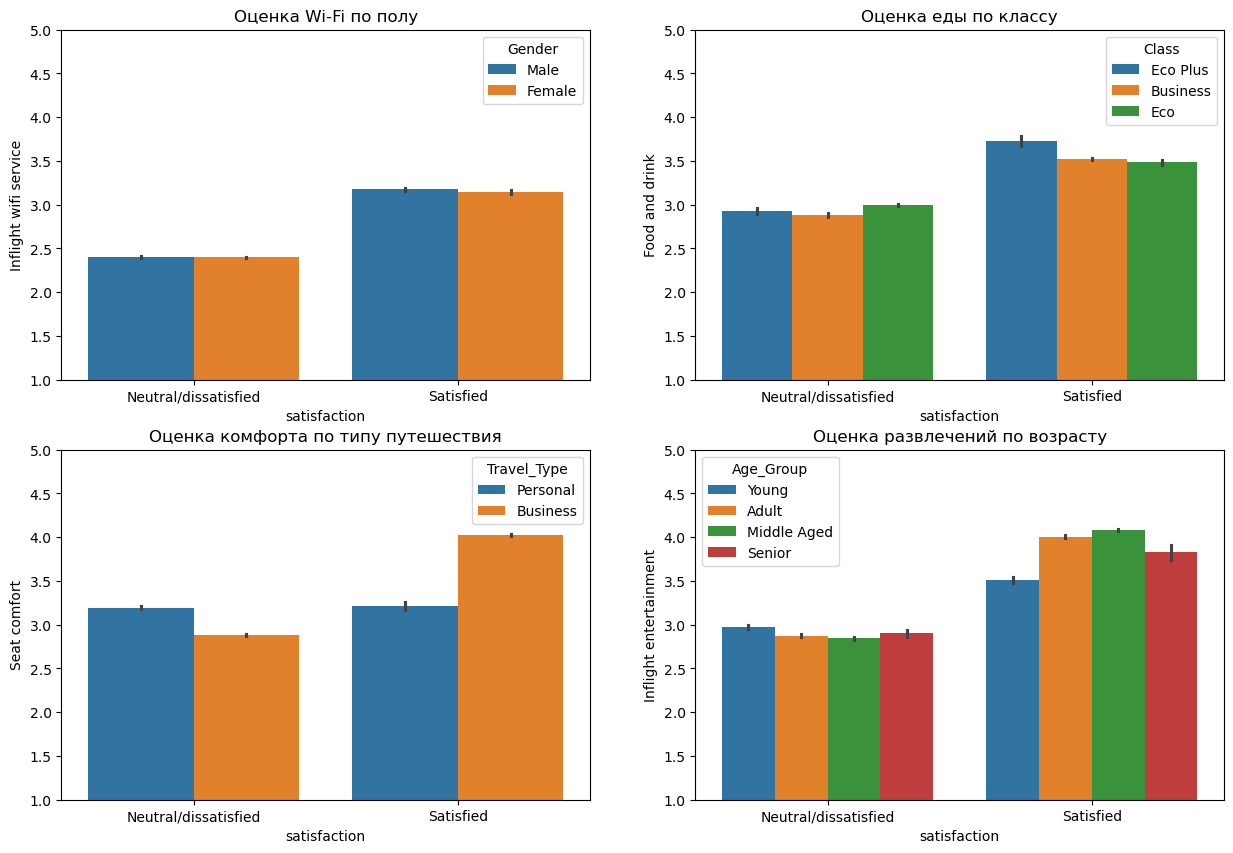

In [43]:
df_plot = df.copy()
df_plot['satisfaction'] = df_plot['satisfaction_label'].map({0: 'Neutral/dissatisfied', 1: 'Satisfied'})
df_plot['Class'] = df_plot['Class_Label'].map({1: 'Business', 2: 'Eco', 3: 'Eco Plus'})
df_plot['Travel_Type'] = df_plot['Type_of_Travel_Label'].map({0: 'Business', 1: 'Personal'})

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

sns.barplot(data=df_plot, x='satisfaction', y='Inflight wifi service', hue='Gender', ax=axes[0,0])
axes[0,0].set_title('Оценка Wi-Fi по полу')
axes[0,0].set_ylim(1, 5)

sns.barplot(data=df_plot, x='satisfaction', y='Food and drink', hue='Class', ax=axes[0,1])
axes[0,1].set_title('Оценка еды по классу')
axes[0,1].set_ylim(1, 5)

sns.barplot(data=df_plot, x='satisfaction', y='Seat comfort', hue='Travel_Type', ax=axes[1,0])
axes[1,0].set_title('Оценка комфорта по типу путешествия')
axes[1,0].set_ylim(1, 5)

sns.barplot(data=df_plot, x='satisfaction', y='Inflight entertainment', hue='Age_Group', ax=axes[1,1])
axes[1,1].set_title('Оценка развлечений по возрасту')
axes[1,1].set_ylim(1, 5)

plt.show()

<Axes: >

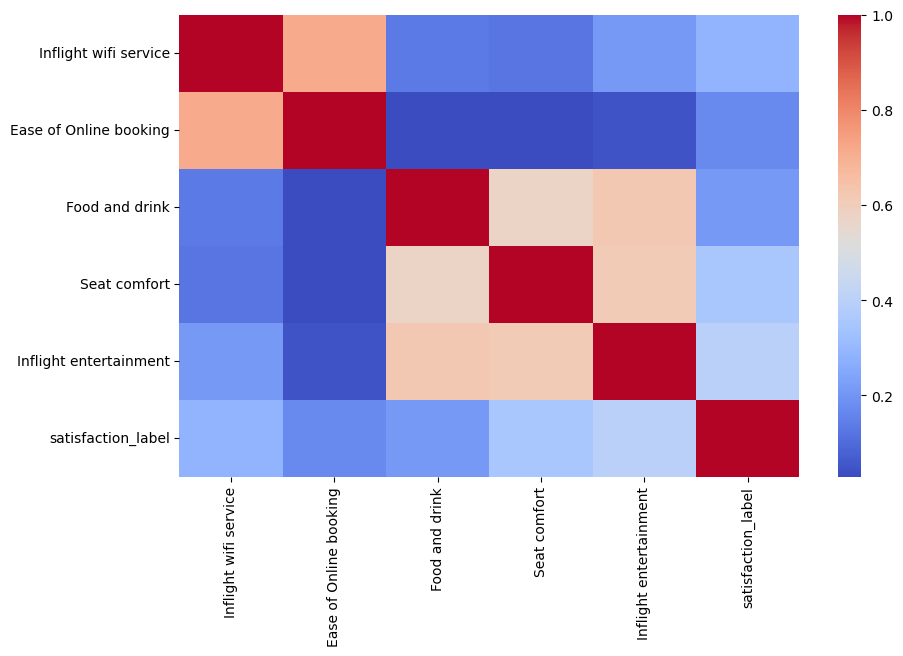

In [44]:
service_columns = ['Inflight wifi service', 'Ease of Online booking', 
                   'Food and drink', 'Seat comfort', 'Inflight entertainment']
plt.figure(figsize=(10, 6))
sns.heatmap(df[service_columns + ['satisfaction_label']].corr(), cmap='coolwarm')

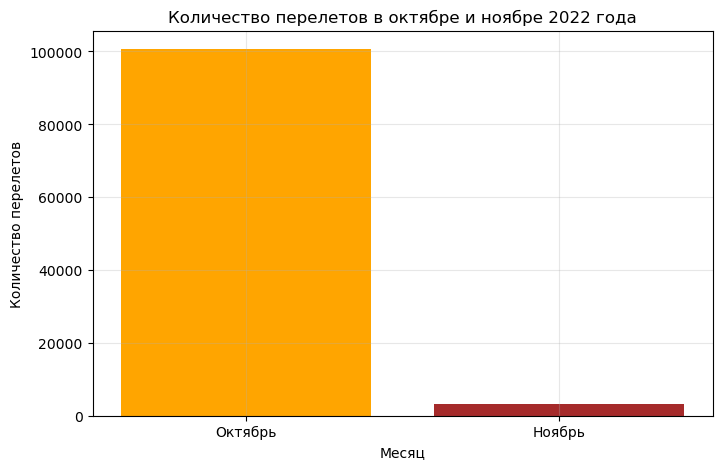

In [45]:
flights_oct_nov = df[(df['Flight_Year'] == 2022) & (df['Flight_Month'].isin([10, 11]))]
monthly_flights = flights_oct_nov['Flight_Month'].value_counts().sort_index()

plt.figure(figsize=(8, 5))
plt.bar(monthly_flights.index, monthly_flights.values, color=['orange', 'brown'])
plt.title('Количество перелетов в октябре и ноябре 2022 года')
plt.xlabel('Месяц')
plt.ylabel('Количество перелетов')
plt.xticks([10, 11], ['Октябрь', 'Ноябрь'])
plt.grid(True, alpha=0.3)
plt.show()

In [46]:
df_cleaned = df[df['Flight_Month'] != 11]

In [47]:
df.to_excel("Обработанные данные.xlsx", index=False)

In [48]:
#КРАТКИЙ ОТЧЕТ ПО АНАЛИЗУ
# В основном, в данных, представленных в таблице, не преобладали пропуски в столбцах за исключением: 'Leg room service', 'Baggage handling', 'Arrival Delay in Minutes'.
#Пустые строки в этих столбцах были заменены на средние или наиболее вероятные значения для упрощения обработки данных в дальнейшем.
# Также были удалены выбросы по возрасту и по датам. В основном, информация пердставлена по перелетам в октябре, однако где-то встречался ноябрь, что можно посчитать за выброс поэтому он также был удален.
# Все нечисловые данные были переведены в числовые посредством обработки категориальных жлементов
# Были построены 4 столбчатых графика, на которых видна средняя оценка удовлетворенности пассажиров по разным показателям.
# Также была построена корреляционный график, демонстрирующий корреляцию оценок пассажиров по разным показателям.

In [49]:
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

In [50]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [51]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [52]:
X = df.drop(columns=[
    'id',
    'satisfaction_label',
    'Gender',
    'Type of Travel',
    'Class',
    'Customer Type',
    'satisfaction',
    'Date'
])
X = X.select_dtypes(include=[np.number])
y = df['satisfaction_label']

In [55]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split

In [62]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X, 
    y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

In [63]:
smote = SMOTE(
    sampling_strategy='auto',
    random_state=42
)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

In [64]:
print("До сэмплирования:")
print(y_train.value_counts())

print("\nПосле сэмплирования:")
print(y_train_smote.value_counts())

До сэмплирования:
satisfaction_label
0    47106
1    36022
Name: count, dtype: int64

После сэмплирования:
satisfaction_label
0    47106
1    47106
Name: count, dtype: int64


In [ ]:
#выровняли данные до единого числа

In [ ]:
def predict_results(model, X_train, X_valid, y_train, y_valid):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_valid)
    
    accuracy = accuracy_score(y_valid, y_pred)
    precision = precision_score(y_valid, y_pred)
    recall = recall_score(y_valid, y_pred)
    f1 = f1_score(y_valid, y_pred)
    print(f"Accuracy: {accuracy:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1-score: {f1:.4f}")
    
    ConfusionMatrixDisplay.from_estimator(model, X_valid, y_valid)
    plt.show()

In [82]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score

In [ ]:
#Логистическая регрессия
lr_model = make_pipeline(
    StandardScaler(),
    LogisticRegression(
        penalty="l2",
        max_iter=1000,
        random_state=42
    )
)

Без SMOTE:
Accuracy: 0.8760, Precision: 0.8700, Recall: 0.8392, F1-score: 0.8543


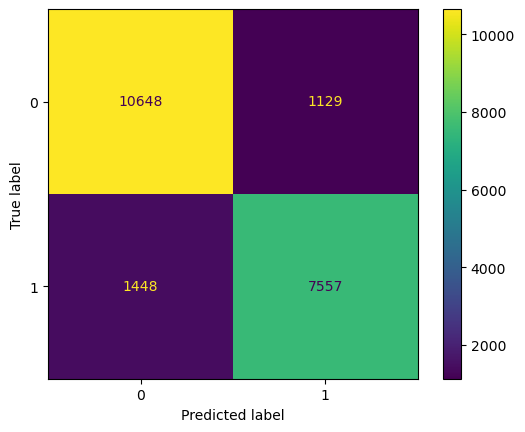


С SMOTE:
Accuracy: 0.8671, Precision: 0.8407, Recall: 0.8554, F1-score: 0.8480


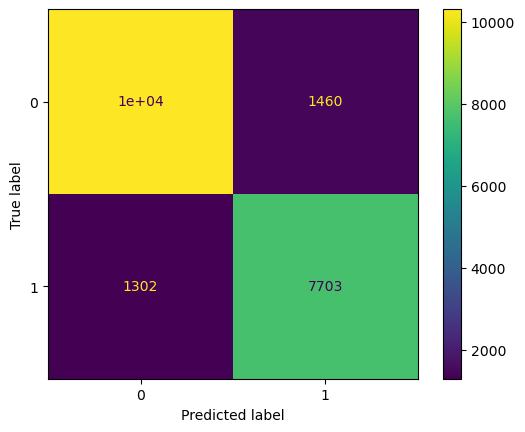

In [68]:
print("Без SMOTE:")
predict_results(lr_model, X_train, X_valid, y_train, y_valid)

print("\nС SMOTE:")
predict_results(lr_model, X_train_smote, X_valid, y_train_smote, y_valid)

In [ ]:
# С методом SMOTE показатели (кроме recall) слегка ухудшились, но незначительно

In [72]:
accuracy = cross_val_score(lr_model, X, y, cv=5, scoring='accuracy').mean()
precision = cross_val_score(lr_model, X, y, cv=5, scoring='precision').mean()
recall = cross_val_score(lr_model, X, y, cv=5, scoring='recall').mean()
f1 = cross_val_score(lr_model, X, y, cv=5, scoring='f1').mean()
print(f"Accuracy: {accuracy:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1-score: {f1:.4f}")

Accuracy: 0.8751, Precision: 0.8712, Recall: 0.8351, F1-score: 0.8528


Accuracy: 0.8760, Precision: 0.8700, Recall: 0.8392, F1-score: 0.8543


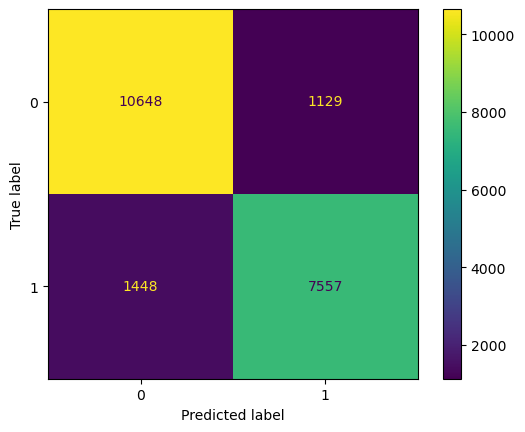

In [73]:
predict_results(lr_model, X_train, X_valid, y_train, y_valid)

Accuracy: 0.8671, Precision: 0.8407, Recall: 0.8554, F1-score: 0.8480


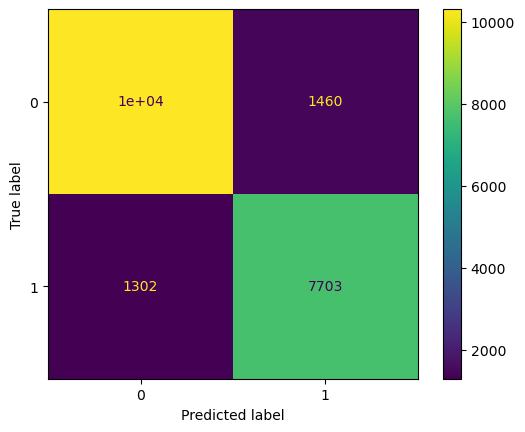

In [74]:
predict_results(lr_model, X_train_smote, X_valid, y_train_smote, y_valid)

In [75]:
accuracy = cross_val_score(lr_model, X, y, cv=5, scoring='accuracy').mean()
precision = cross_val_score(lr_model, X, y, cv=5, scoring='precision').mean()
recall = cross_val_score(lr_model, X, y, cv=5, scoring='recall').mean()
f1 = cross_val_score(lr_model, X, y, cv=5, scoring='f1').mean()
print(f"Accuracy: {accuracy:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1-score: {f1:.4f}")

Accuracy: 0.8751, Precision: 0.8712, Recall: 0.8351, F1-score: 0.8528


In [84]:
logistic_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(random_state=42))
])

logistic_grid = {
    'classifier__penalty': ['l2', 'l1'], 
    'classifier__solver': ['liblinear', 'saga'],
    'classifier__C': np.logspace(-2, 2, 5),
    'classifier__max_iter': [1000, 2000],
    'classifier__class_weight': [None, 'balanced'] 
}

grid_search = GridSearchCV(
    estimator=logistic_pipeline,
    param_grid=logistic_grid,
    cv=3, 
    scoring='f1',
    n_jobs=-1,
    verbose=2
)
grid_search.fit(X_train_smote, y_train_smote)
print("\nЛучшие параметры:", grid_search.best_params_)

Fitting 3 folds for each of 80 candidates, totalling 240 fits

Лучшие параметры: {'classifier__C': np.float64(0.1), 'classifier__class_weight': None, 'classifier__max_iter': 1000, 'classifier__penalty': 'l2', 'classifier__solver': 'liblinear'}


In [85]:
best_dt_model = grid_search.best_estimator_

In [86]:
accuracy = cross_val_score(best_dt_model, X, y, cv=5, scoring='accuracy').mean()
precision = cross_val_score(best_dt_model, X, y, cv=5, scoring='precision').mean()
recall = cross_val_score(best_dt_model, X, y, cv=5, scoring='recall').mean()
f1 = cross_val_score(best_dt_model, X, y, cv=5, scoring='f1').mean()

print(f"Accuracy: {accuracy:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1-score: {f1:.4f}")

Accuracy: 0.8750, Precision: 0.8711, Recall: 0.8351, F1-score: 0.8527


In [ ]:
# Вывод: с семплированием данные практически не изменились

In [98]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

In [88]:
knn_model = KNeighborsClassifier(
    n_neighbors=5,
    metric="euclidean",
    weights="uniform",
)

Accuracy: 0.7362, Precision: 0.7117, Recall: 0.6575, F1-score: 0.6836


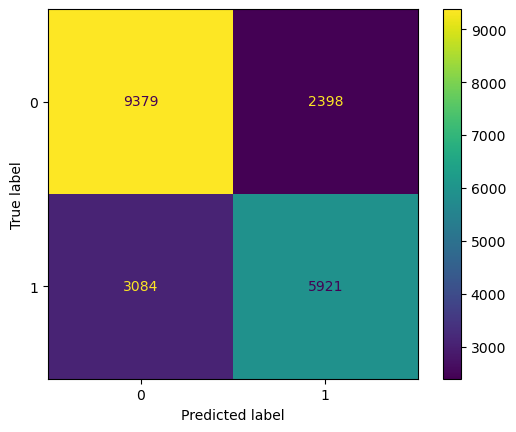

In [89]:
predict_results(knn_model, X_train, X_valid, y_train, y_valid)

Accuracy: 0.7191, Precision: 0.6611, Recall: 0.7215, F1-score: 0.6900


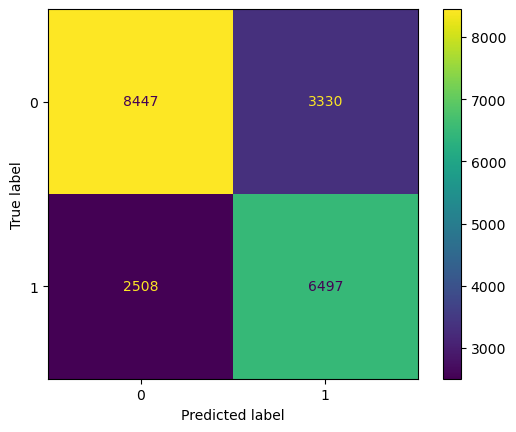

In [90]:
predict_results(knn_model, X_train_smote, X_valid, y_train_smote, y_valid)

In [93]:
accuracy = cross_val_score(knn_model, X, y, cv=5, scoring='accuracy').mean()
precision = cross_val_score(knn_model, X, y, cv=5, scoring='precision').mean()
recall = cross_val_score(knn_model, X, y, cv=5, scoring='recall').mean()
f1 = cross_val_score(knn_model, X, y, cv=5, scoring='f1').mean()

print(f"Accuracy: {accuracy:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1-score: {f1:.4f}")

Accuracy: 0.7404, Precision: 0.7178, Recall: 0.6608, F1-score: 0.6881


In [100]:
knn_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])

param_grid_knn = {
    'knn__n_neighbors': [3, 5, 7, 9, 11],
    'knn__weights': ['uniform', 'distance'],
    'knn__metric': ['euclidean', 'manhattan']
}

grid_knn = GridSearchCV(
    knn_pipeline,
    param_grid_knn,
    cv=3,
    scoring='f1',
    n_jobs=1,
    verbose=2 
)
grid_knn.fit(X, y)
print("Лучшие параметры:", grid_knn.best_params_)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
[CV] END knn__metric=euclidean, knn__n_neighbors=3, knn__weights=uniform; total time=   9.7s
[CV] END knn__metric=euclidean, knn__n_neighbors=3, knn__weights=uniform; total time=   9.2s
[CV] END knn__metric=euclidean, knn__n_neighbors=3, knn__weights=uniform; total time=   9.5s
[CV] END knn__metric=euclidean, knn__n_neighbors=3, knn__weights=distance; total time=   6.9s
[CV] END knn__metric=euclidean, knn__n_neighbors=3, knn__weights=distance; total time=   6.8s
[CV] END knn__metric=euclidean, knn__n_neighbors=3, knn__weights=distance; total time=   6.4s
[CV] END knn__metric=euclidean, knn__n_neighbors=5, knn__weights=uniform; total time=   9.6s
[CV] END knn__metric=euclidean, knn__n_neighbors=5, knn__weights=uniform; total time=   9.5s
[CV] END knn__metric=euclidean, knn__n_neighbors=5, knn__weights=uniform; total time=   9.9s
[CV] END knn__metric=euclidean, knn__n_neighbors=5, knn__weights=distance; total time=   6.5s
[CV] 

In [101]:
best_knn_model = grid_search.best_estimator_

In [102]:
accuracy = cross_val_score(best_knn_model, X_valid, y_valid, cv=5, scoring='accuracy').mean()
precision = cross_val_score(best_knn_model, X_valid, y_valid, cv=5, scoring='precision').mean()
recall = cross_val_score(best_knn_model, X_valid, y_valid, cv=5, scoring='recall').mean()
f1 = cross_val_score(best_knn_model, X_valid, y_valid, cv=5, scoring='f1').mean()

print(f"Accuracy: {accuracy:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1-score: {f1:.4f}")

Accuracy: 0.8768, Precision: 0.8725, Recall: 0.8381, F1-score: 0.8549


In [126]:
param_grid_knn = {
    'n_neighbors': range(3, 16),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}
grid_knn = GridSearchCV(
    KNeighborsClassifier(),
    param_grid_knn,
    cv=5,
    scoring='f1',
    n_jobs=-1
)
grid_knn.fit(X_train_smote, y_train_smote)
print("Лучшие параметры:", grid_search.best_params_)

KeyboardInterrupt: 

In [105]:
best_knn_model = grid_search.best_estimator_

In [106]:
accuracy = cross_val_score(best_knn_model, X_valid, y_valid, cv=5, scoring='accuracy').mean()
precision = cross_val_score(best_knn_model, X_valid, y_valid, cv=5, scoring='precision').mean()
recall = cross_val_score(best_knn_model, X_valid, y_valid, cv=5, scoring='recall').mean()
f1 = cross_val_score(best_knn_model, X_valid, y_valid, cv=5, scoring='f1').mean()

print(f"Accuracy: {accuracy:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1-score: {f1:.4f}")

Accuracy: 0.8768, Precision: 0.8725, Recall: 0.8381, F1-score: 0.8549


In [ ]:
#С семплированием показатели остались такими же

In [107]:
from sklearn.tree import DecisionTreeClassifier

In [108]:
dt_model = DecisionTreeClassifier(
    criterion="gini", 
    max_depth=5, 
    min_samples_split=2, 
    min_samples_leaf=1,
    max_features=None, 
    min_impurity_decrease=0.0,
    random_state=42
)

Accuracy: 0.9084, Precision: 0.9088, Recall: 0.8766, F1-score: 0.8924


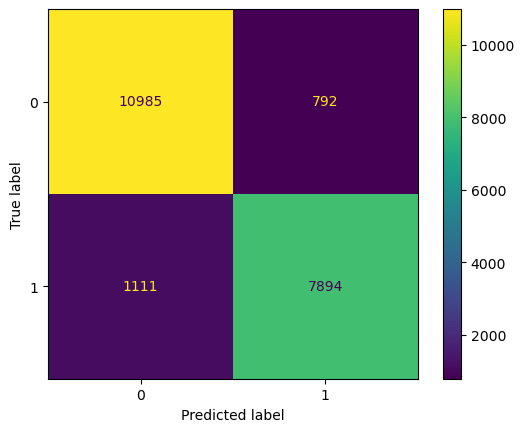

In [109]:
predict_results(dt_model, X_train, X_valid, y_train, y_valid)

Accuracy: 0.9052, Precision: 0.8889, Recall: 0.8928, F1-score: 0.8909


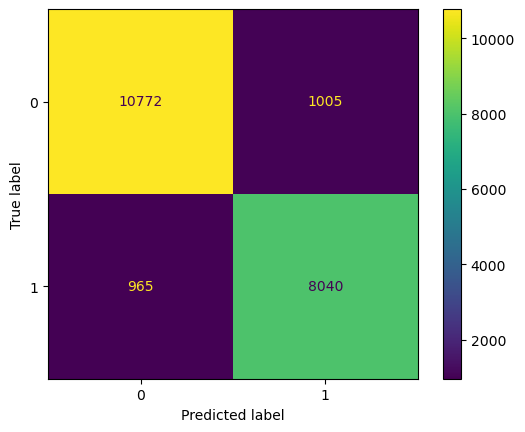

In [110]:
predict_results(dt_model, X_train_smote, X_valid, y_train_smote, y_valid)

In [111]:
accuracy = cross_val_score(dt_model, X, y, cv=5, scoring='accuracy').mean()
precision = cross_val_score(dt_model, X, y, cv=5, scoring='precision').mean()
recall = cross_val_score(dt_model, X, y, cv=5, scoring='recall').mean()
f1 = cross_val_score(dt_model, X, y, cv=5, scoring='f1').mean()

print(f"Accuracy: {accuracy:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1-score: {f1:.4f}")

Accuracy: 0.9058, Precision: 0.9045, Recall: 0.8750, F1-score: 0.8895


In [113]:
param_grid_dt = {
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_leaf': [1, 2, 5, 10],
    'criterion': ['gini', 'entropy']
}
grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),  
    param_grid=param_grid_dt,  
    cv=5,  
    scoring='f1' 
)

grid_search.fit(X, y)

print("Лучшие параметры:", grid_search.best_params_)

Лучшие параметры: {'criterion': 'entropy', 'max_depth': 15, 'min_samples_leaf': 1}


In [114]:
best_dt_model = grid_search.best_estimator_

In [115]:
accuracy = cross_val_score(best_dt_model, X_valid, y_valid, cv=5, scoring='accuracy').mean()
precision = cross_val_score(best_dt_model, X_valid, y_valid, cv=5, scoring='precision').mean()
recall = cross_val_score(best_dt_model, X_valid, y_valid, cv=5, scoring='recall').mean()
f1 = cross_val_score(best_dt_model, X_valid, y_valid, cv=5, scoring='f1').mean()

print(f"Accuracy: {accuracy:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1-score: {f1:.4f}")

Accuracy: 0.9405, Precision: 0.9394, Recall: 0.9223, F1-score: 0.9307


In [117]:
param_grid_dt = {
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_leaf': [1, 2, 5, 10],
    'criterion': ['gini', 'entropy']
}
grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),  
    param_grid=param_grid_dt,  
    cv=5,  
    scoring='f1' 
)

grid_search.fit(X_train_smote, y_train_smote)

print("Лучшие параметры:", grid_search.best_params_)

Лучшие параметры: {'criterion': 'entropy', 'max_depth': 15, 'min_samples_leaf': 2}


In [118]:
best_dt_model = grid_search.best_estimator_

In [119]:
accuracy = cross_val_score(best_dt_model, X_valid, y_valid, cv=5, scoring='accuracy').mean()
precision = cross_val_score(best_dt_model, X_valid, y_valid, cv=5, scoring='precision').mean()
recall = cross_val_score(best_dt_model, X_valid, y_valid, cv=5, scoring='recall').mean()
f1 = cross_val_score(best_dt_model, X_valid, y_valid, cv=5, scoring='f1').mean()

print(f"Accuracy: {accuracy:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1-score: {f1:.4f}")

Accuracy: 0.9417, Precision: 0.9456, Recall: 0.9184, F1-score: 0.9318


In [ ]:
# Для дерева решений показатели улучшились

In [120]:
feature_importances = best_dt_model.feature_importances_

feature_importance_df = pd.DataFrame({
    "Признак": X.columns,
    "Важность": feature_importances
})

feature_importance_df = feature_importance_df.sort_values(by="Важность", ascending=False)

In [121]:
feature_importance_df

,Признак,Важность
7,Online boarding,0.305488
2,Inflight wifi service,0.197362
20,Type_of_Travel_Label,0.134299
12,Baggage handling,0.070493
18,Customer_Label,0.057831
21,Class_Label,0.053858
11,Leg room service,0.029189
0,Age,0.028054
13,Checkin service,0.020629
8,Seat comfort,0.016134


In [ ]:
#Краткий анализ
# Самым важным показателем оказалась оценка удобства Online Boarding, что может считаться ошибкой, так как данный показатель не является определяющим общее впечатление пассажира о полете.
# Самый высокий показатель F1 = 0.9318 выдает дерево решений со следующими лучшими параметрами, отобранными моделью: {'criterion': 'entropy', 'max_depth': 15, 'min_samples_leaf': 2}
# Самый высокий показатель Accuracy = 0.9417 также демонстрирует дерево решений, однако можно сказать, что в целом показатели разных моделей не отличаются кардинально, но наиболее худшие показатели у логистической регрессии